In [ ]:
  # Instalamos pyspark )
!pip install pyspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("TP5").getOrCreate()

Listo! Ya tienes un entorno PySpark funcionando como en Databricks.


In [ ]:

df_vuelos = spark.read.csv("/content/airlines_a.csv", header=True, inferSchema=True)
df_aerolineas = spark.read.csv("/content/L_UNIQUE_CARRIERS.csv", header=True, inferSchema=True)

# Seleccionar columnas
cols_pedidas = ['OP_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME', 'DEP_DELAY',
                'ARR_TIME', 'ARR_DELAY', 'DISTANCE', 'FL_DATE']
df_vuelos_limpio = df_vuelos.select(cols_pedidas)

# Unir tablas (Join) para tener la descripción
df_completo = df_vuelos_limpio.join(df_aerolineas, df_vuelos_limpio.OP_CARRIER == df_aerolineas.Code, "left")

df_completo.show(5) # En Colab usamos .show() en vez de display()

+----------+------+----+--------+---------+--------+---------+--------+----------+----+--------------------+
|OP_CARRIER|ORIGIN|DEST|DEP_TIME|DEP_DELAY|ARR_TIME|ARR_DELAY|DISTANCE|   FL_DATE|Code|         Description|
+----------+------+----+--------+---------+--------+---------+--------+----------+----+--------------------+
|        XE|   DCA| EWR|  1058.0|     -2.0|  1206.0|      4.0|   199.0|2009-01-01|  XE|ExpressJet Airlin...|
|        XE|   EWR| IAD|  1509.0|     -1.0|  1624.0|     -8.0|   213.0|2009-01-01|  XE|ExpressJet Airlin...|
|        XE|   EWR| DCA|  1059.0|     -1.0|  1201.0|     -9.0|   199.0|2009-01-01|  XE|ExpressJet Airlin...|
|        XE|   DCA| EWR|  1249.0|      9.0|  1345.0|    -12.0|   199.0|2009-01-01|  XE|ExpressJet Airlin...|
|        XE|   IAD| EWR|  1705.0|    -10.0|  1822.0|    -38.0|   213.0|2009-01-01|  XE|ExpressJet Airlin...|
+----------+------+----+--------+---------+--------+---------+--------+----------+----+--------------------+
only showing top 5 

In [ ]:
from pyspark.sql.functions import col, avg

# 1. Cantidad de vuelos por empresa
vuelos_por_empresa = df_completo.groupBy("Description").count()
vuelos_por_empresa.show()

# 2. Calcular demora total y Promedio
df_calculado = df_completo.withColumn("Total_Delay", col("DEP_DELAY") + col("ARR_DELAY"))
df_promedios = df_calculado.groupBy("Description").agg(avg("Total_Delay").alias("Promedio_Demora"))

df_promedios.show()

+--------------------+------+
|         Description| count|
+--------------------+------+
|   Endeavor Air Inc.| 36044|
|SkyWest Airlines ...| 70876|
|   PSA Airlines Inc.| 20206|
|United Air Lines ...| 50363|
|Frontier Airlines...| 11404|
|Southwest Airline...|153986|
|ExpressJet Airlin...| 37114|
|Continental Air L...| 34723|
|Northwest Airline...| 36777|
|ExpressJet Airlin...| 36998|
|     JetBlue Airways| 26353|
|AirTran Airways C...| 30972|
|     US Airways Inc.| 56841|
|           Envoy Air| 55579|
|Hawaiian Airlines...|  9897|
|Alaska Airlines Inc.| 18205|
|Delta Air Lines Inc.| 56991|
|  Mesa Airlines Inc.| 30925|
|American Airlines...| 76921|
+--------------------+------+

+--------------------+------------------+
|         Description|   Promedio_Demora|
+--------------------+------------------+
|   Endeavor Air Inc.|3.4868439848013026|
|SkyWest Airlines ...| 12.31894773539409|
|   PSA Airlines Inc.|25.867054726885296|
|United Air Lines ...| 9.056577373106483|
|Frontier Airli

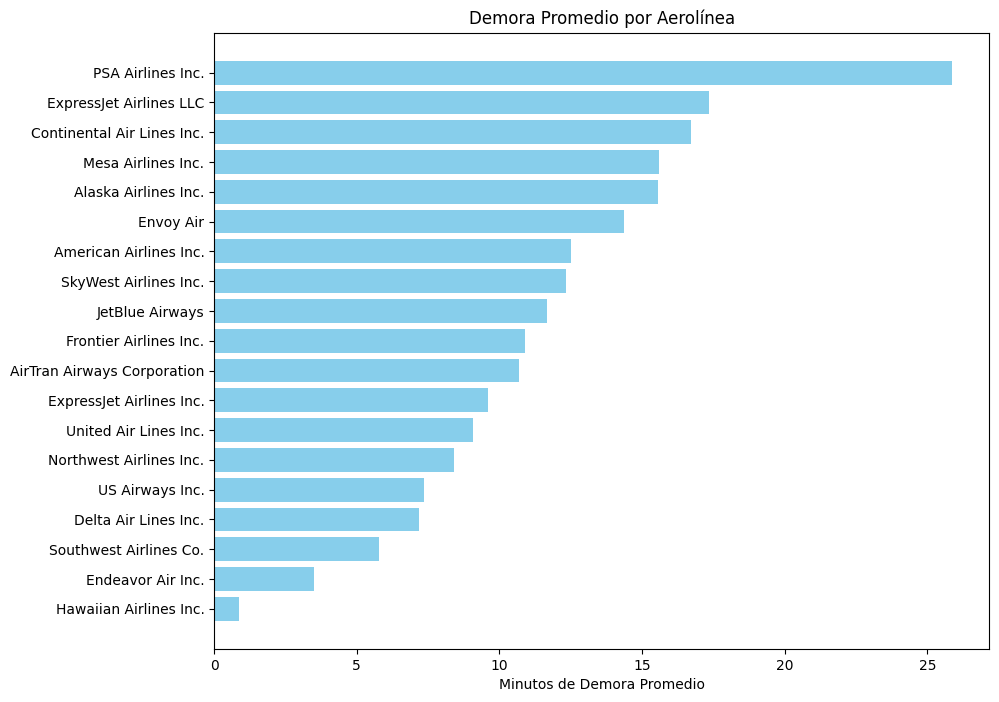

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


pdf_grafico = df_promedios.toPandas()
pdf_grafico = pdf_grafico.sort_values('Promedio_Demora')

plt.figure(figsize=(10, 8))
plt.barh(pdf_grafico['Description'], pdf_grafico['Promedio_Demora'], color='skyblue')
plt.xlabel('Minutos de Demora Promedio')
plt.title('Demora Promedio por Aerolínea')
plt.show()

In [ ]:
%%writefile mapper.py
import sys

# Lee desde la entrada estándar (stdin)
for line in sys.stdin:
    # Eliminar espacios en blanco al inicio y final
    line = line.strip()
    # Dividir la línea en palabras
    words = line.split()

    # Emitir cada palabra con un conteo de 1
    for word in words:
        # Escribimos al stdout
        print(f'{word}\t1')

Writing mapper.py


In [ ]:
%%writefile reducer.py
import sys

current_word = None
current_count = 0
word = None

# Lee desde la entrada estándar
for line in sys.stdin:
    line = line.strip()
    # Parsea la entrada (palabra [tab] 1)
    word, count = line.split('\t', 1)

    try:
        count = int(count)
    except ValueError:
        continue

    # Si la palabra es igual a la actual, sumamos
    if current_word == word:
        current_count += count
    else:
        # Si cambió la palabra, imprimimos el resultado de la anterior
        if current_word:
            print(f'{current_word}\t{current_count}')
        current_count = count
        current_word = word

# Imprimir la última palabra
if current_word == word:
    print(f'{current_word}\t{current_count}')

Writing reducer.py
